In [1]:
import pandas as pd

Load_Datset

In [2]:
df=pd.read_csv("Bank Customer Churn Prediction.csv")

In [ ]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Renaming column names to improve readability

In [4]:
df=df.rename(columns={
                     'credit_score':'Credit_Score',
                     'country':'Country',
                     'gender':'Gender',
                     'tenure':'Tenure',
                     'products_number':'NumOfProducts',
                     'credit_card':'HasCreditCard',
                     'active_member':'IsActiveMember',
                     'estimated_salary':'EstimatedSalary',
                     'churn':'Churn',
                     'balance':'Balance',
                     'age':'Age'
                     })

In [5]:
df.head()

,customer_id,Credit_Score,Country,Gender,Age,Tenure,Balance,NumOfProducts,HasCreditCard,IsActiveMember,EstimatedSalary,Churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.shape

(10000, 12)

In [7]:
df.columns

Index(['customer_id', 'Credit_Score', 'Country', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCreditCard', 'IsActiveMember',
       'EstimatedSalary', 'Churn'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      10000 non-null  int64  
 1   Credit_Score     10000 non-null  int64  
 2   Country          10000 non-null  str    
 3   Gender           10000 non-null  str    
 4   Age              10000 non-null  int64  
 5   Tenure           10000 non-null  int64  
 6   Balance          10000 non-null  float64
 7   NumOfProducts    10000 non-null  int64  
 8   HasCreditCard    10000 non-null  int64  
 9   IsActiveMember   10000 non-null  int64  
 10  EstimatedSalary  10000 non-null  float64
 11  Churn            10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [9]:
df["Churn"].unique()

array([1, 0])

In [10]:
df["Churn"].value_counts()

Churn
0    7963
1    2037
Name: count, dtype: int64

In [11]:
df["Churn"]=df["Churn"].map({
    0 :'No',
    1 :'yes'
})

In [12]:
df["Churn"].value_counts()

Churn
No     7963
yes    2037
Name: count, dtype: int64

Missing value analysis

In [13]:
df.isnull().sum()

customer_id        0
Credit_Score       0
Country            0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCreditCard      0
IsActiveMember     0
EstimatedSalary    0
Churn              0
dtype: int64

There are no missing values identified in the dataset.
 All features are fully populated, which ensures data completeness and allows  us to proceed directly to model training without any imputation

In [14]:
df.duplicated().sum()

np.int64(0)

A check for duplicate rows returned a count of zero, confirming that every record in the dataset represents a unique customer. The absence of duplicate data ensures that our statistical analysis and future model predictions will not be biased by redundant information.

In [15]:
df.dtypes

customer_id          int64
Credit_Score         int64
Country                str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCreditCard        int64
IsActiveMember       int64
EstimatedSalary    float64
Churn                  str
dtype: object

In [16]:
import numpy as np

In [17]:
Numerical_columns=df.select_dtypes(include=np.number).columns.to_list()

In [18]:
Numerical_columns.remove('customer_id')

In [19]:
Numerical_columns

['Credit_Score',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCreditCard',
 'IsActiveMember',
 'EstimatedSalary']

In [20]:
Categorical_columns=df.select_dtypes(exclude=np.number).columns.to_list()

In [21]:
Categorical_columns

['Country', 'Gender', 'Churn']

In [22]:
df=df.drop(columns='customer_id')

In [23]:
df.describe()

,Credit_Score,Age,Tenure,Balance,NumOfProducts,HasCreditCard,IsActiveMember,EstimatedSalary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df["Country"].value_counts()

Country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [26]:
Categorical_columns

['Country', 'Gender', 'Churn']

Univariate analysis of Categorical columns

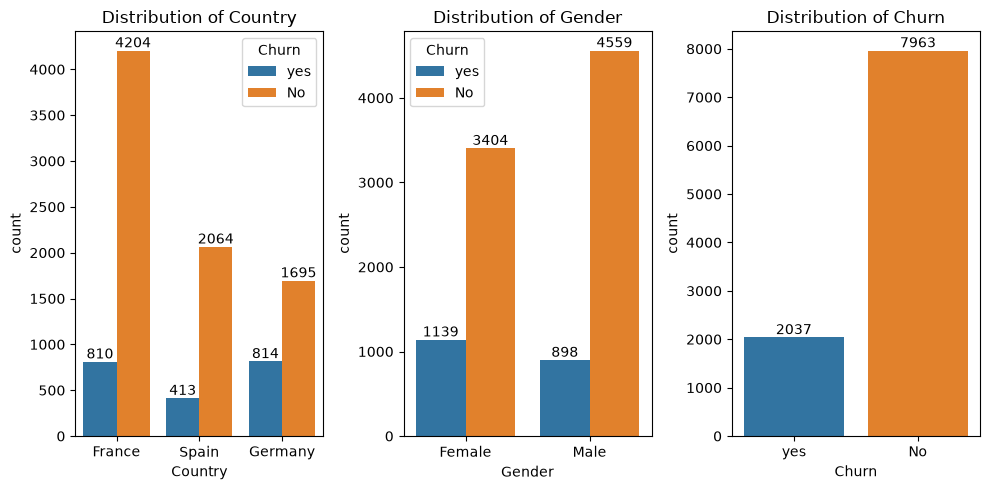

In [27]:
fig,axes=plt.subplots(ncols=3,nrows=1,figsize=(10,5))
for i, col in enumerate(Categorical_columns):
    sns.countplot(data=df,x=col,hue='Churn',ax=axes[i]).set_title(f'Distribution of {col}')
    for container in axes[i].containers:
        axes[i].bar_label(container)
plt.tight_layout()
plt.show()

Distribution of Churn (Target Variable)

​Observation: The dataset is highly imbalanced. 
Out of the total customers, 7,963 customers have stayed with the bank ("No" Churn), 
while 2,037 customers have left the bank ("yes" Churn).

​Insight: The overall churn rate is approximately 20.37%. This serves as a baseline value for our predictive models.


 Country  vs churn analysis

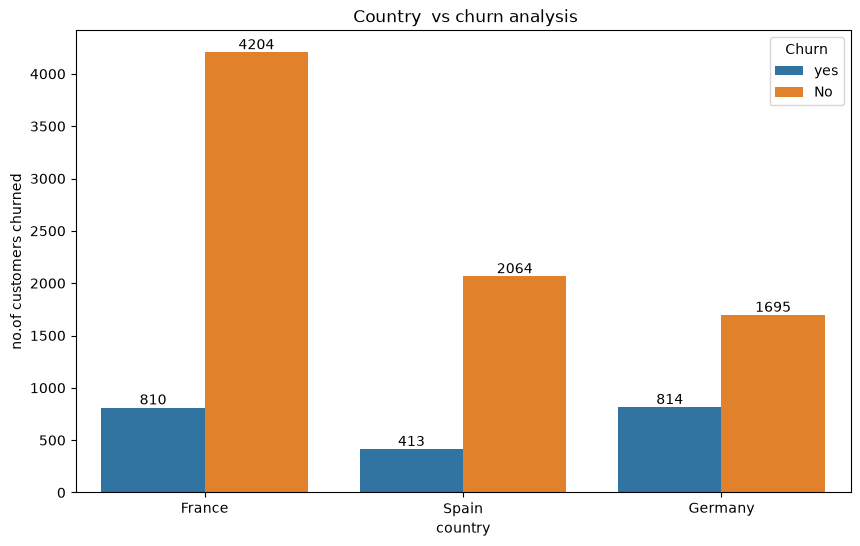

In [28]:
plt.figure(figsize=(10,6))

ax=sns.countplot(data=df,x='Country',hue="Churn")
plt.bar_label(ax.containers[0])
plt.bar_label(ax.containers[1])
plt.title(" Country  vs churn analysis")
plt.xlabel("country")
plt.ylabel("no.of customers churned")
plt.show()



​Country vs. Churn Analysis:

​France & Spain: France has the highest number of customers overall. Both France and Spain show relatively low and stable churn rates 


​Germany (Critical Risk): Germany has a significantly high churn rate. Despite having fewer total customers than France, it has the highest absolute number of churned customers (814), meaning roughly 32% of German customers are leaving.

​Action Item: The business should prioritize investigating the German market to understand and fix the high customer loss.

 Gender vs churn analysis

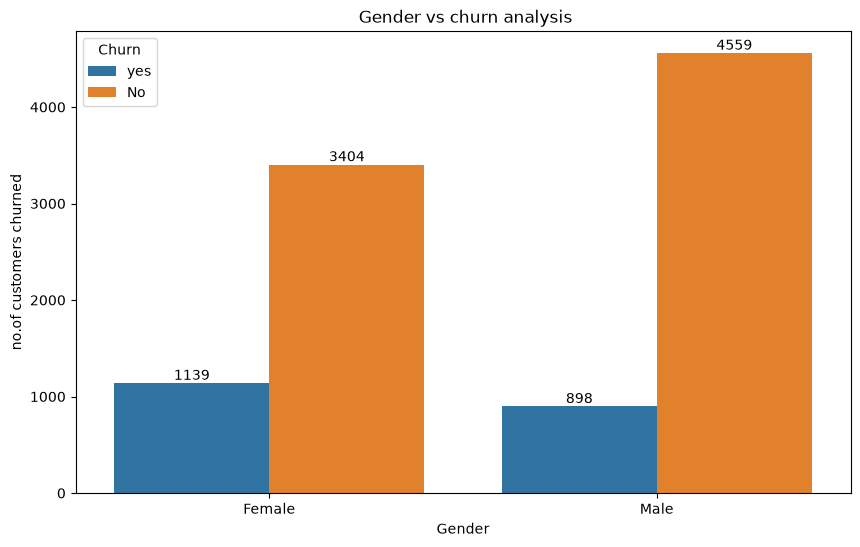

In [29]:
plt.figure(figsize=(10,6))

ax=sns.countplot(data=df,x='Gender',hue="Churn")
plt.bar_label(ax.containers[0])
plt.bar_label(ax.containers[1])
plt.title(" Gender vs churn analysis")
plt.xlabel("Gender")
plt.ylabel("no.of customers churned")
plt.show()

​Gender vs. Churn Analysis:

​Higher Risk in Females: Female customers show a significantly higher tendency to leave the bank.
 A total of 1,139 females have churned compared to only 898 males, despite there being fewer female customers overall in the dataset.


​Higher Loyalty in Males: Male customers show much stronger retention, with 4,559 staying with the bank, 
resulting in a notably lower churn rate compared to females.

​Business Takeaway: There is a clear gender gap in customer retention. 
The business needs to investigate why female customers are dissatisfied—potentially looking into product preferences, targeted customer service, or specialized financial features to improve female retention.

In [30]:
Numerical_columns

['Credit_Score',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCreditCard',
 'IsActiveMember',
 'EstimatedSalary']

Univariate analysis of numerical columns

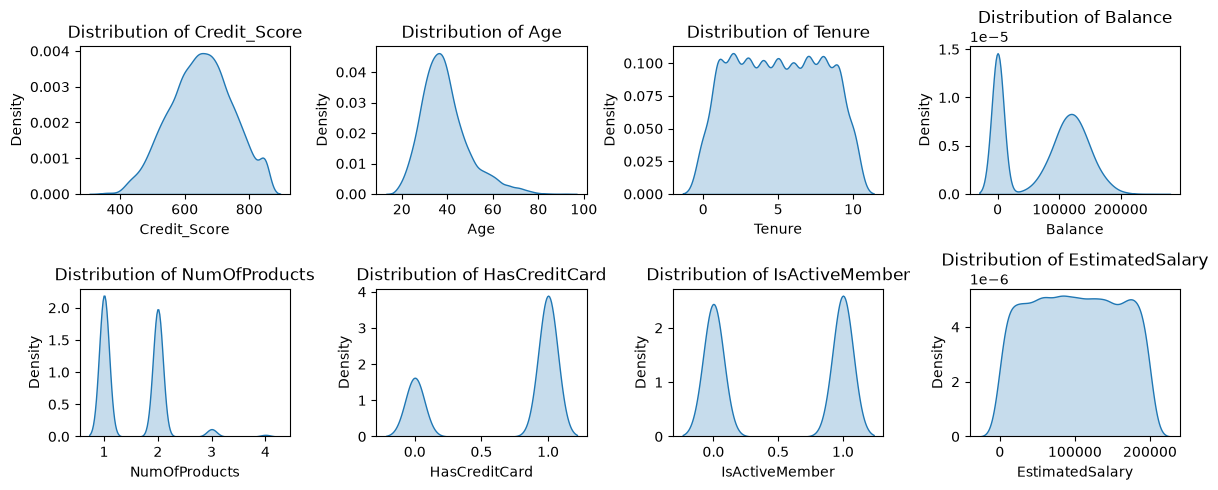

In [31]:
fig,axes=plt.subplots(ncols=4,nrows=2,figsize=(12,5))
ax=axes.flatten()
for i, col in enumerate(Numerical_columns):
    sns.kdeplot(data=df,x=col,ax=ax[i],fill=True).set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

​Univariate Analysis Insights

​Credit_Score: Shows a roughly normal (bell-shaped) distribution centered around 600–650, with a slight left skew (a few customers have exceptionally low credit scores).

​Age: Right-skewed distribution. The majority of the bank's customers are young to middle-aged adults, concentrated between 30 and 45 years old, with a long tail extending into elderly age groups.

​Tenure: Shows a uniform distribution. Customers are evenly distributed across all tenure lengths (from 0 to 10 years), indicating steady customer acquisition over the years.

​Balance: This feature is strictly bimodal. There is a huge spike at 0, showing a massive segment of customers with empty or inactive balances. The remaining active balances are normally distributed around 100,000 to 125,000.

​NumOfProducts: Highly discrete distribution. The vast majority of customers only purchase 1 or 2 products from the bank. Extremely few customers hold 3 or 4 products.

​HasCreditCard & IsActiveMember: These are binary/categorical flags represented numerically:
​HasCreditCard: Strongly skewed toward 1.0. A significant majority of the bank's customers own a credit card.

​IsActiveMember: Fairly evenly split between active (1.0) and inactive (0.0) members, though active members have a slightly higher peak.

​EstimatedSalary: Completely uniform distribution spanning from 0 to 200,000. This implies that the salary values are evenly distributed across the customer base, which is typical for synthetic or uniformly sampled income fields.

Bivariate analysis of numerical columns

credit score vs churn

In [32]:
df.columns

Index(['Credit_Score', 'Country', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCreditCard', 'IsActiveMember', 'EstimatedSalary',
       'Churn'],
      dtype='str')

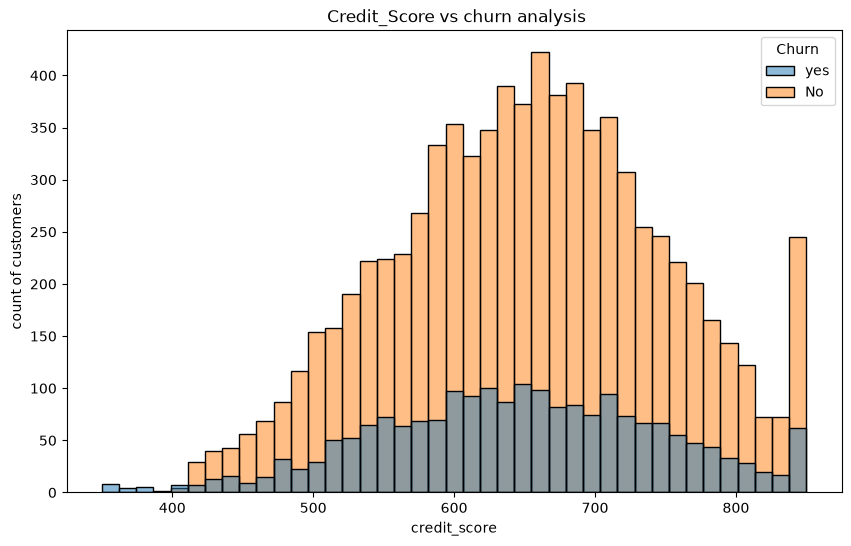

In [33]:
plt.figure(figsize=(10,6))
ax=sns.histplot(data=df,hue='Churn',x='Credit_Score')
plt.title(" Credit_Score vs churn analysis")
plt.xlabel("credit_score")
plt.ylabel("count of customers")
plt.show()

"The histogram illustrates a normal distribution of customer credit scores centered between 600 and 700. 
When evaluating the churn status (Yes/No), the ratio of churned customers remains visually consistent across all credit score brackets. This indicates that credit score is not a primary driving factor for customer churn in this dataset, as high-score individuals leave the bank at a proportional rate to low-score individuals."

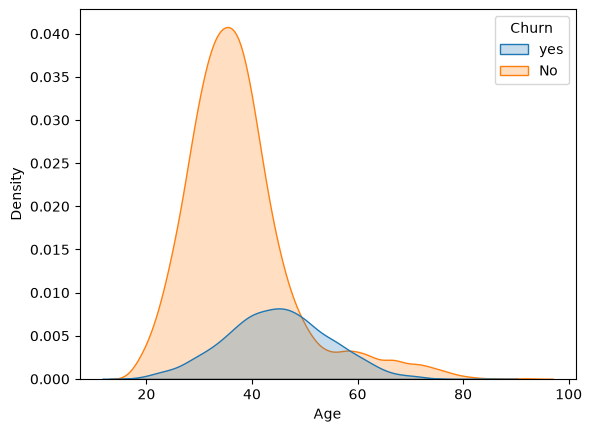

In [34]:
sns.kdeplot(data=df,x='Age',fill=True,hue='Churn')
plt.show()

* *Younger customers (aged 20-40)* are highly loyal and prefer to stay with the bank.
* *Middle-aged customers (aged 40-50)* show the highest rate of leaving (churning) the bank.
* Therefore, *Age is a strong predictor* of churn, and the bank should focus its retention strategies on the 40-50 age group.


In [35]:
df

,Credit_Score,Country,Gender,Age,Tenure,Balance,NumOfProducts,HasCreditCard,IsActiveMember,EstimatedSalary,Churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,yes
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,No
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,yes
3,699,France,Female,39,1,0.00,2,0,0,93826.63,No
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,No
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,No
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,No
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,yes
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,yes


In [36]:
#from sklearn.preprocessing import LabelEncoder

In [37]:
#le=LabelEncoder()

In [38]:
#df["Country"]=le.fit_transform(df["Country"])

In [39]:
#le.classes_

In [40]:
#print(dict(zip(le.classes_,le.transform(le.classes_))))

In [41]:
#le=LabelEncoder()
#df["Gender"]=le.fit_transform(df["Gender"])
#print(dict(zip(le.classes_,le.transform(le.classes_))))

In [42]:
#le=LabelEncoder()
#df["Churn"]=le.fit_transform(df["Churn"])
#print(dict(zip(le.classes_,le.transform(le.classes_))))

In [43]:
df.head()

,Credit_Score,Country,Gender,Age,Tenure,Balance,NumOfProducts,HasCreditCard,IsActiveMember,EstimatedSalary,Churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,yes
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,No
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,yes
3,699,France,Female,39,1,0.00,2,0,0,93826.63,No
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,No


In [44]:
from sklearn.preprocessing import OneHotEncoder

In [45]:
encoder=OneHotEncoder()

In [46]:
Categorical_columns

['Country', 'Gender', 'Churn']

In [47]:
df=pd.get_dummies(df,columns=["Country","Gender"],dtype=int,drop_first=True)

In [48]:
df

,Credit_Score,Age,Tenure,Balance,NumOfProducts,HasCreditCard,IsActiveMember,EstimatedSalary,Churn,Country_Germany,Country_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,yes,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,No,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,yes,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,No,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,No,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,No,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,No,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,yes,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,yes,1,0,1


In [49]:
df["Churn"]=df["Churn"].map({
    'No':0,
    'yes':1
})

In [50]:
df.head()

,Credit_Score,Age,Tenure,Balance,NumOfProducts,HasCreditCard,IsActiveMember,EstimatedSalary,Churn,Country_Germany,Country_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [51]:
corr_matrix=df.corr()

In [52]:
corr_matrix

,Credit_Score,Age,Tenure,Balance,NumOfProducts,HasCreditCard,IsActiveMember,EstimatedSalary,Churn,Country_Germany,Country_Spain,Gender_Male
Credit_Score,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094,0.005538,0.004780,-0.002857
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323,0.046897,-0.001685,-0.027544
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001,-0.000567,0.003868,0.014733
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533,0.401110,-0.134892,0.012087
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820,-0.010419,0.009039,-0.021859
HasCreditCard,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138,0.010577,-0.013480,0.005766
IsActiveMember,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128,-0.020486,0.016732,0.022544
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097,0.010297,-0.006482,-0.008112
Churn,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000,0.173488,-0.052667,-0.106512
Country_Germany,0.005538,0.046897,-0.000567,0.401110,-0.010419,0.010577,-0.020486,0.010297,0.173488,1.000000,-0.332084,-0.024628


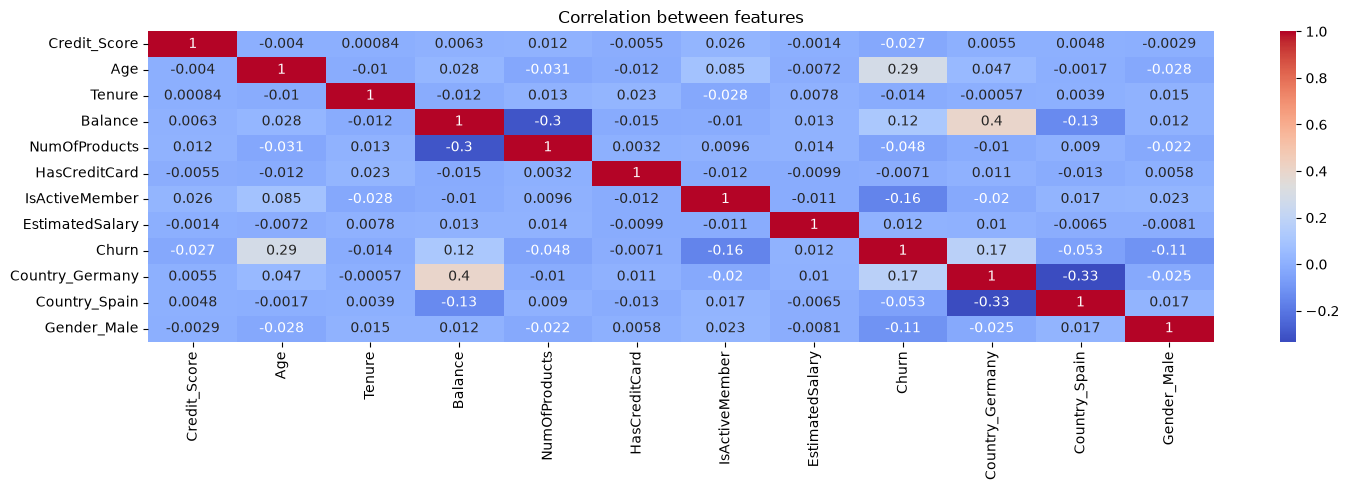

In [53]:
plt.figure(figsize=(15,5))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title("Correlation between features")
plt.tight_layout()
plt.show()

Based on the correlation heatmap:

Weak Linear Correlations: Most independent features (like Credit_Score, EstimatedSalary, Gender_Male, and Tenure) show a correlation value very close to 0 with the target variable Churn. This indicates that there are no strong, straightforward linear relationships between these individual features and customer churn.

Top Contributing Indicators: The features showing noticeable linear trends with churn are Age (0.29) (older customers are more likely to churn), Country_Germany (0.17) (customers in Germany are more likely to churn), IsActiveMember (-0.16) (active members are less likely to churn), and Balance (0.12). Additionally, Country_Germany shows a moderate positive correlation with Balance (0.40).

 We Must Include All Features: Just because a feature has a correlation close to 0 doesn't mean it is useless. Correlation only measures linear relationships.

In a real-world banking scenario, customer behavior is complex. For example, a low credit score might not cause churn on its own, but a customer with a low credit score combined with a high balance and low tenure might be at high risk.

Final Strategy: To capture these complex, hidden interactions and geographic patterns, we will include all features in our dataset—including the newly created One-Hot Encoded features—rather than dropping the low-correlation ones

In [54]:
df.columns

Index(['Credit_Score', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCreditCard', 'IsActiveMember', 'EstimatedSalary', 'Churn',
       'Country_Germany', 'Country_Spain', 'Gender_Male'],
      dtype='str')

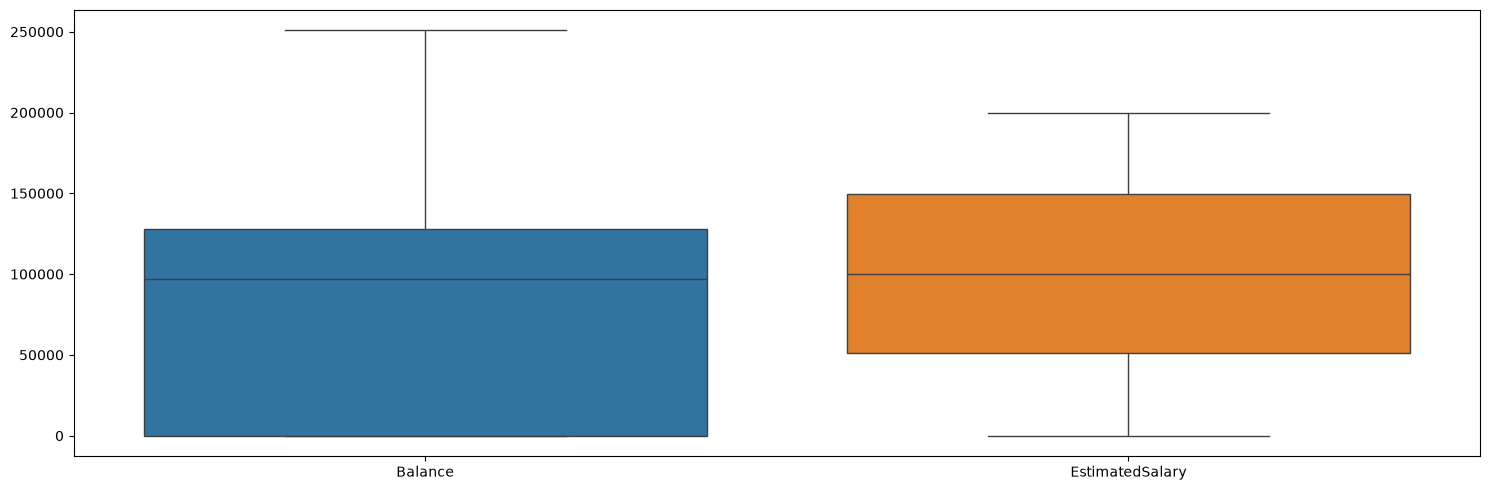

In [55]:
plt.figure(figsize=(15,5))
sns.boxplot(data=df[['Balance', 'EstimatedSalary']])       
plt.tight_layout()
plt.show()

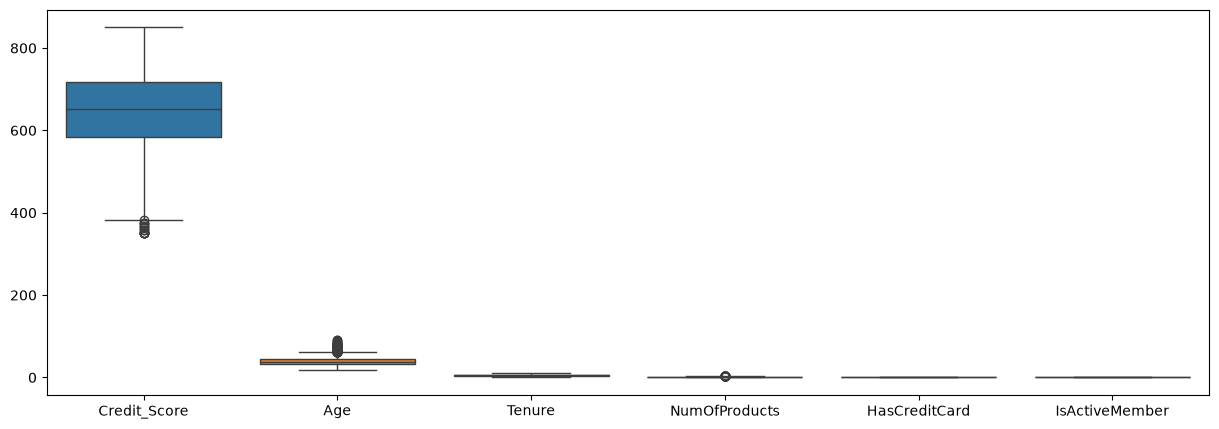

In [56]:
plt.figure(figsize=(15,5))
sns.boxplot(data=df[['Credit_Score', 'Age','Tenure', 
       'NumOfProducts', 'HasCreditCard', 'IsActiveMember']])
plt.show()

Outlier Treatment & Insights:

​Age (Slight Correlation): Age shows a minor correlation with customer churn. The older age outliers represent genuine senior citizen profiles, making their retention valuable for capturing this specific age-group behavior.

​Credit Score (No Impact on Churn): Analysis reveals that Credit_Score does not significantly impact churn, as customers with both high and low credit scores are churning uniformly. 

​Conclusion: Because these outliers represent valid real-world data points and their distribution aligns with the overall churn patterns, no outliers will be removed to avoid loss of organic data.

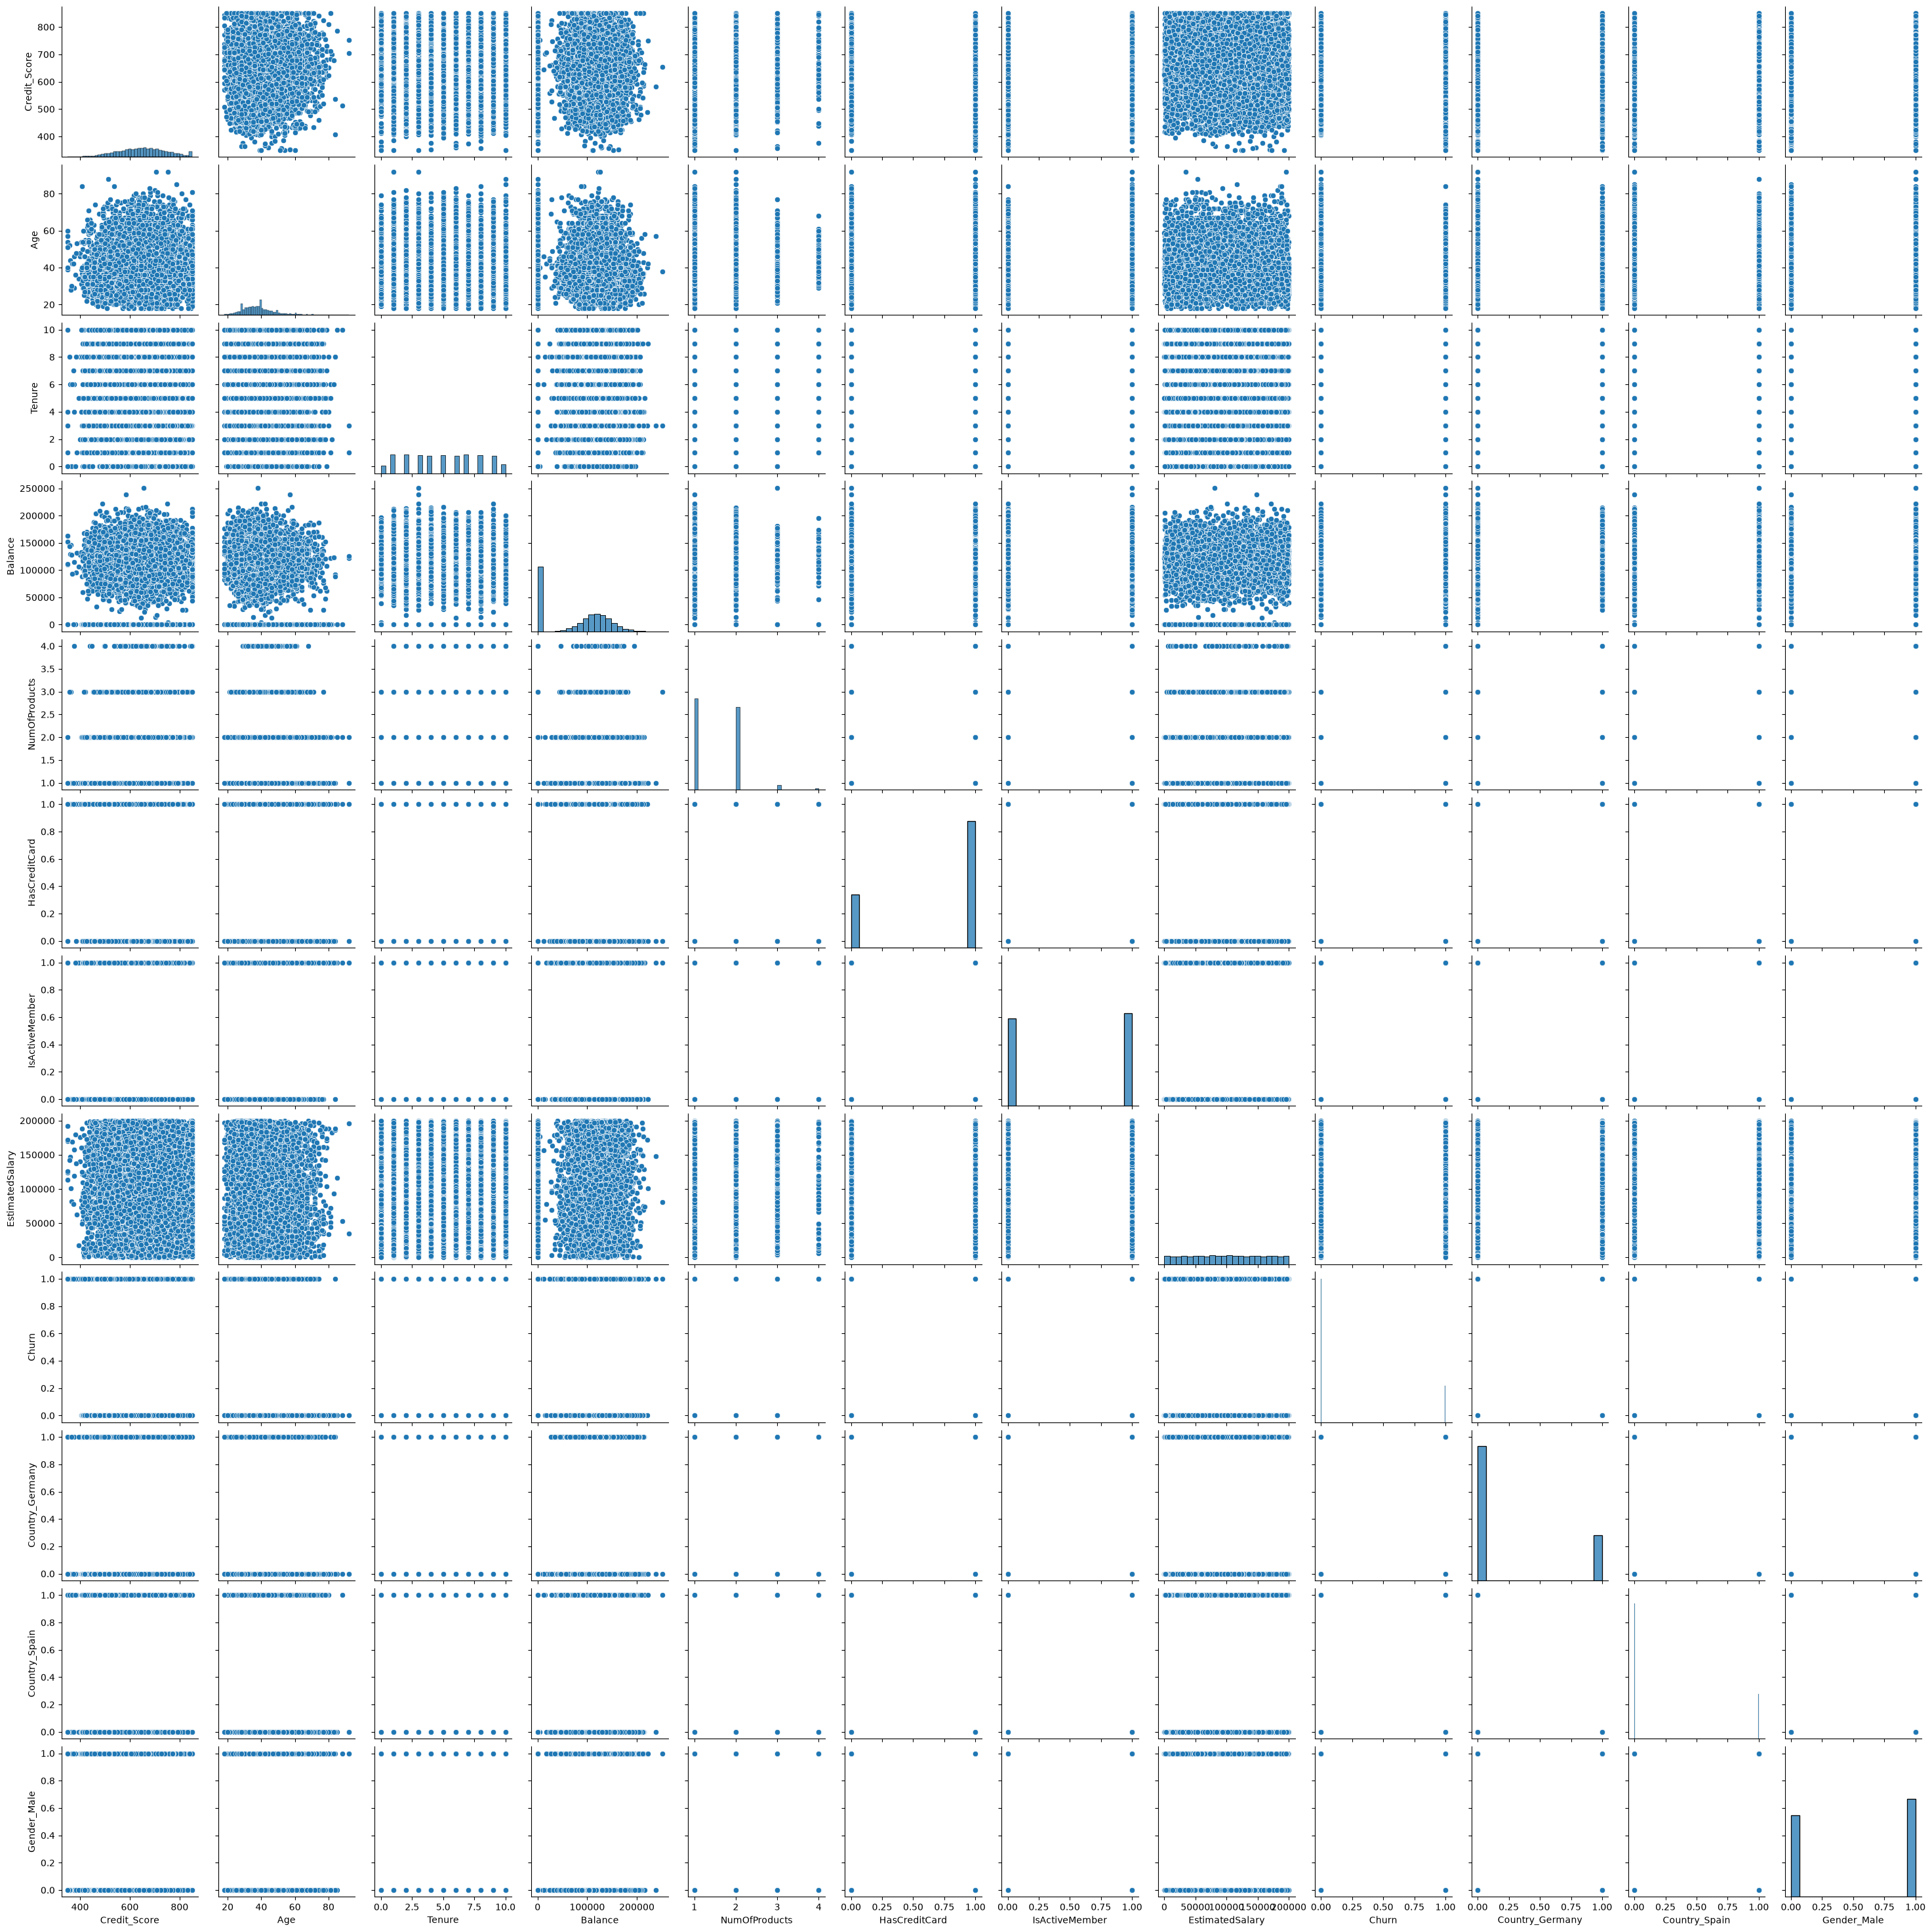

In [57]:
sns.pairplot(data=df)
plt.show()



Feature Selection & Justification: 

​Low Linear Correlation: The correlation heatmap indicates that most independent features have weak linear relationships with the target variable Churn (with Age having the maximum correlation of 0.29). ​

Non-Linear Interactions: Since customer churn is a complex behavioral pattern, features with low linear correlation can still possess strong non-linear relationships and interactions that simple correlation cannot capture.

 ​Multicollinearity Check: There is no significant multicollinearity between the independent variables, meaning every feature provides unique information to the dataset. 
 
 ​Final Decision: Dropping features based purely on low correlation might lead to a loss of critical data signals. Therefore, all features are retained to allow robust tree-based algorithms (like Random Forest or XGBoost) to effectively model the underlying non-linear patterns.


In [58]:
x=df.drop(columns='Churn')

In [59]:
x.shape

(10000, 11)

In [60]:
y=df['Churn']

In [61]:
y.shape

(10000,)

In [62]:
type(x)

pandas.DataFrame

In [63]:
type(y)

pandas.Series

In [64]:
from sklearn.model_selection import train_test_split

In [65]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)


In [66]:
from sklearn.preprocessing import StandardScaler

In [67]:
scaler=StandardScaler()

In [68]:
Numerical_columns

['Credit_Score',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCreditCard',
 'IsActiveMember',
 'EstimatedSalary']

In [69]:
x_train[Numerical_columns]=scaler.fit_transform(x_train[Numerical_columns])

In [70]:
x_test[Numerical_columns]=scaler.transform(x_test[Numerical_columns])




In [71]:
df

,Credit_Score,Age,Tenure,Balance,NumOfProducts,HasCreditCard,IsActiveMember,EstimatedSalary,Churn,Country_Germany,Country_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [72]:
x_train

,Credit_Score,Age,Tenure,Balance,NumOfProducts,HasCreditCard,IsActiveMember,EstimatedSalary,Country_Germany,Country_Spain,Gender_Male
4901,0.218351,1.916619,-1.731689,1.629928,0.813111,-1.539736,0.969789,-1.382844,0,0,1
4375,2.057280,0.202109,1.041750,-0.246244,-0.911043,0.649462,-1.031152,-1.195890,1,0,1
6698,0.758602,-0.750397,0.348390,-1.221027,-0.911043,-1.539736,-1.031152,-0.683422,0,0,0
9805,-0.082942,-0.559895,0.695070,1.574101,-0.911043,-1.539736,0.969789,-0.985396,0,0,1
1101,0.530034,-0.940898,1.388429,-1.221027,0.813111,0.649462,-1.031152,-0.868375,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
5734,1.205347,1.440366,1.041750,-0.104830,-0.911043,0.649462,0.969789,-0.543502,0,0,1
5191,0.311856,1.821368,-1.385009,-1.221027,-0.911043,0.649462,0.969789,-1.736478,0,0,0
5390,0.862496,-0.083643,-1.385009,-1.221027,2.537266,-1.539736,-1.031152,-0.146754,0,0,0
860,0.156015,0.392610,1.041750,1.824777,-0.911043,0.649462,-1.031152,-0.054895,0,0,1


classifiers model building

In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [74]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier


Since the dataset is imbalanced, setting class_weight='balanced' (and scale_pos_weight in XGBoost) penalizes misclassifications of the minority class more heavily. This forces the model to give equal importance to both classes during training, improving its ability to detect the minority class.

In [75]:
clasifiers={
    'LogisticRegression':LogisticRegression(class_weight='balanced'),
    'KNeighborsClassifier':KNeighborsClassifier(),
    'RandomForestClassifier':RandomForestClassifier(random_state=42,class_weight='balanced'),
    'svm classifier':SVC(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'GaussianNB':GaussianNB(),
    'XGBClassifier':XGBClassifier(scale_pos_weight=4)
}

In [76]:
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix

In [77]:
result={}

In [78]:

for name,clf in clasifiers.items():
    clf.fit(x_train,y_train)
    y_pred=clf.predict(x_test)
    accuracy=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    report=classification_report(y_test,y_pred)
    matrix=confusion_matrix(y_test,y_pred)

    result[name]={'Accuracy':accuracy,'f1 score': f1}
    print(f'{name} \n { classification_report(y_test,y_pred)} \n')
    print(f'{name} \n { confusion_matrix(y_test,y_pred)} \n')
 
result_df=pd.DataFrame(result).T
result_df

LogisticRegression 
               precision    recall  f1-score   support

           0       0.91      0.71      0.80      2003
           1       0.38      0.71      0.49       497

    accuracy                           0.71      2500
   macro avg       0.64      0.71      0.64      2500
weighted avg       0.80      0.71      0.74      2500
 

LogisticRegression 
 [[1423  580]
 [ 146  351]] 

KNeighborsClassifier 
               precision    recall  f1-score   support

           0       0.87      0.94      0.91      2003
           1       0.66      0.44      0.53       497

    accuracy                           0.84      2500
   macro avg       0.77      0.69      0.72      2500
weighted avg       0.83      0.84      0.83      2500
 

KNeighborsClassifier 
 [[1892  111]
 [ 280  217]] 

RandomForestClassifier 
               precision    recall  f1-score   support

           0       0.90      0.91      0.91      2003
           1       0.62      0.59      0.61       497

    acc

,Accuracy,f1 score
LogisticRegression,0.7096,0.491597
KNeighborsClassifier,0.8436,0.526061
RandomForestClassifier,0.8472,0.606186
svm classifier,0.8576,0.513661
DecisionTreeClassifier,0.7916,0.486700
GaussianNB,0.8304,0.457801
XGBClassifier,0.8308,0.602070


Detailed Analysis & Insights


​Because your target dataset is imbalanced (as indicated use of class_weight='balanced' and scale_pos_weight=4), Accuracy alone is misleading.

​For instance, SVM achieves the highest accuracy (85.76%), but its F1-Score drops to 0.5137, meaning it heavily predicts the majority (negative) class and misses many minority (positive) churn cases.



Top Performing Models:

​Random Forest and XGBoost  are best performing

​Random Forest Classifier: Achieves 84.72% Accuracy and 0.6062 F1-Score. Handling class imbalance via class_weight='balanced' allowed it to maintain high precision and recall simultaneously.

​XGBoost Classifier: Achieves 83.08% Accuracy and 0.6021 F1-Score. Setting scale_pos_weight=4 significantly boosted its ability to capture the minority class.

Underperforming Models:

​Logistic Regression: Shows a relatively low accuracy (70.96%) and F1-score (0.4916), indicating that customer churn in this dataset has non-linear feature relationships.

​Gaussian Naive Bayes: While accuracy seems decent (83.04%), the lowest F1-score (0.4578) reveals poor recall on the target class.


​Hyperparameter Tuning for RandomForestClassifier

In [79]:
model=RandomForestClassifier(class_weight='balanced')

In [80]:
param_grid={
    'n_estimators' :[50,100,200],
    'max_depth':[10,20,30],
    'min_samples_split':[2,5,10]
}

In [81]:
from sklearn.model_selection import GridSearchCV

In [82]:
grid_search=GridSearchCV(model,param_grid,scoring='f1',cv=3,n_jobs=-1,verbose=2)

In [83]:
grid_search.fit(x_train,y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ht='balanced')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_

In [84]:
grid_search.best_estimator_

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fash

In [85]:
grid_search.best_params_

{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}

In [86]:
grid_search.best_score_

np.float64(0.6225424525177315)

In [87]:
best_random_forest=grid_search.best_estimator_

In [88]:
y_pred=best_random_forest.predict(x_test)

In [89]:
accuracy=accuracy_score(y_test,y_pred)

In [90]:
f1=f1_score(y_test,y_pred)

In [91]:
report=classification_report(y_test,y_pred)

In [92]:
matrix=confusion_matrix(y_test,y_pred)

In [93]:
print("Hyper parameter tuned Random forest claasifier Accuracy :",accuracy)
print("Hyper parameter tuned Random forest claasifier F1 Score :",f1)
print("Hyper parameter tuned Random forest claasifier Confusion matrix:" +"\n",matrix)

print(report)

Hyper parameter tuned Random forest claasifier Accuracy : 0.8436
Hyper parameter tuned Random forest claasifier F1 Score : 0.6177908113391984
Hyper parameter tuned Random forest claasifier Confusion matrix:
 [[1793  210]
 [ 181  316]]
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      2003
           1       0.60      0.64      0.62       497

    accuracy                           0.84      2500
   macro avg       0.75      0.77      0.76      2500
weighted avg       0.85      0.84      0.85      2500



Though SVM had high accuracy, Random Forest was chosen because it handled the imbalanced churn data much better with a higher initial F1-score (0.6061).

​Impact of Tuning:

Hyperparameter tuning increased the Recall from 59% to 63%, successfully catching 21 more actual churned customers (True Positives increased from 294 to 315).

After hyperparameter tuning, the Random Forest model achieved an accuracy of ~84% and an F1-score of ~62%. To further improve the F1-score and handle class imbalance,  plan to experiment with SMOTE (Synthetic Minority Over-sampling Technique) in future iterations.

In [94]:
from imblearn.over_sampling import SMOTE

In [95]:
smote=SMOTE(random_state=42)

In [96]:
x_train_resampled,y_train_resampled=smote.fit_resample(x_train,y_train)

In [97]:
x_train.shape

(7500, 11)

In [98]:
x_train_resampled.shape

(11920, 11)

In [99]:
y_train.shape

(7500,)

In [100]:
y_train_resampled.shape

(11920,)

After resampling X_train and y_train using SMOTE, we fit the model using the previously tuned Random Forest hyperparameters to evaluate if the F1-score improves.

In [101]:
model1=RandomForestClassifier(max_depth= 20,min_samples_split=2, n_estimators= 100)


In [102]:
model1.fit(x_train_resampled,y_train_resampled)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [103]:
y_pred_resampled=model1.predict(x_test)

In [104]:
accuracy=accuracy_score(y_test,y_pred_resampled)

In [105]:
accuracy

0.83

In [106]:
f1=f1_score(y_test,y_pred_resampled)
f1

0.5885769603097774

In [107]:
from sklearn.metrics import classification_report,confusion_matrix,precision_score,recall_score

In [108]:
precision=precision_score(y_test,y_pred_resampled)
precision

0.5671641791044776

In [109]:
recall=recall_score(y_test,y_pred_resampled)

In [110]:
recall

0.6116700201207244

In [111]:
print(classification_report(y_test,y_pred_resampled))



              precision    recall  f1-score   support

           0       0.90      0.88      0.89      2003
           1       0.57      0.61      0.59       497

    accuracy                           0.83      2500
   macro avg       0.73      0.75      0.74      2500
weighted avg       0.84      0.83      0.83      2500



In [112]:
print(confusion_matrix(y_test,y_pred_resampled))

[[1771  232]
 [ 193  304]]


| Model Scenario | Accuracy | F1 Score (Class 1) | Recall (Class 1) | True Positives (Caught Churns) |
| :--- | :--- | :--- | :--- | :--- |
| *Tuned Random Forest (No SMOTE)* | 84.44% | 0.62 | 0.63 (63%) | 315 / 497 |
| *Tuned Random Forest + SMOTE* | 83.00% | 0.59 | 0.61 (61%) | 303 / 497 |


Evaluating SMOTE Resampling with Tuned Random Forest:

Applying SMOTE prior to training with tuned Random Forest hyperparameters yielded a slightly lower overall F1-score (0.59 vs 0.62) and Recall (0.61 vs 0.63) compared to the tuned model without resampling.

Conclusion on Resampling:

This indicates that synthetic oversampling introduced minor noise into the decision boundary, confirming that algorithmic tuning without SMOTE performs better for this dataset.

In [113]:
xg_new=XGBClassifier()

In [114]:
param_grid={
    'learning_rate':[0.01,0.05,0.1,0.2],
     'n_estimators':[100,200,300],
     'max_depth':[3,5,7],
     'min_child_weight':[1,3,5],
     'scale_pos_weight':[1,3,4,5]

}

In [115]:
grid_search=GridSearchCV(estimator=xg_new,param_grid=param_grid,scoring='f1',cv=5,n_jobs=-1,verbose=1)

In [116]:
grid_search.fit(x_train,y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr

In [117]:
best_xgb=grid_search.best_estimator_

In [118]:
y_pred=best_xgb.predict(x_test)

In [119]:
grid_search.best_params_

{'learning_rate': 0.05,
 'max_depth': 7,
 'min_child_weight': 1,
 'n_estimators': 100,
 'scale_pos_weight': 3}

In [120]:
accuracy=accuracy_score(y_test,y_pred)
report=classification_report(y_test,y_pred)
f1=f1_score(y_test,y_pred)
matrix=confusion_matrix(y_test,y_pred)



In [121]:
print("hyperparameter tuned xgboost classifier")
print("Accuracy :",accuracy)
print("F1 score :",f1)
print(f'Confusion matrix : \n {matrix}')
print(f'Classification report : \n {report}')

hyperparameter tuned xgboost classifier
Accuracy : 0.8344
F1 score : 0.6208791208791209
Confusion matrix : 
 [[1747  256]
 [ 158  339]]
Classification report : 
               precision    recall  f1-score   support

           0       0.92      0.87      0.89      2003
           1       0.57      0.68      0.62       497

    accuracy                           0.83      2500
   macro avg       0.74      0.78      0.76      2500
weighted avg       0.85      0.83      0.84      2500



Model Comparison

 Metric | Tuned Random Forest | Tuned XGBoost | Best Choice |
| :--- | :--- | :--- | :--- |
| Accuracy | 84.44% | 83.44% | RF (Slightly higher overall) |
| F1 Score | 0.6182 | 0.6208 | XGBoost |
| Recall (Class 1 - Churn) | 0.63 (63%) | 0.68 (68%) | XGBoost (Key Metric) |
| True Positives (Detected Churns) | 315 / 497 | 339 / 497 | XGBoost (+24 extra churners caught) |
| False Negatives (Missed Churns) | 182 | 158 | XGBoost (Lower risk) |

XGBoost model is selected for final Deployment

Reasons:

​Higher Recall for Minority Class (68% vs 63%):

In customer churn prediction, catching churning customers is the primary goal.
 XGBoost successfully detected 339 actual churners, whereas Random Forest only caught 315. 
 That is 24 additional high-risk customers identified by XGBoost.


​Better Overall F1 Score (0.6208 vs 0.6182):

XGBoost achieves a higher F1 score, demonstrating a superior trade-off between Precision and Recall for the imbalanced class.

​Fewer Missed Churners (False Negatives):

XGBoost reduced missed churners down to 158 (compared to 182 in Random Forest), minimizing the business risk of losing undetected customers.



Final Conclusion:

​"Although Random Forest achieved a slightly higher raw accuracy (84.44% vs 83.44%), the Hyperparameter-Tuned XGBoost Classifier is selected for deployment.

 XGBoost demonstrated superior capability in detecting minority class instances, achieving a higher Recall of 68% (339 detected churners) and an overall higher F1-score of 0.6208, making it the most business-aligned model for churn prevention."

model save

In [122]:
import joblib

In [123]:
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [124]:
joblib.dump(best_xgb,'xgb_model.pkl')
print("model saved successfully")

model saved successfully


In [125]:
joblib.dump(x_train.columns.tolist(),"model_columns.pkl")
print("columns saved successfully")


columns saved successfully
